In [25]:
from tdc.single_pred import Tox
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)

RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

In [26]:
df = pd.read_csv('../data/processed/toxicity_dataset_with_descriptors.csv')

## Advanced Analysis: Outliers & Distributions

In [27]:
# Outlier detection
from scipy.stats import zscore

descriptor_cols = df.columns.difference(['Drug_ID', 'Y', 'canonical_smiles'])

outlier_summary = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()
    
    # IQR method
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outliers = ((valid_data < lower) | (valid_data > upper)).sum()
    
    # Z-score method (|z| > 3)
    z_scores = np.abs(zscore(valid_data))
    z_outliers = (z_scores > 3).sum()
    
    outlier_summary[col] = {'IQR': iqr_outliers, 'Z-score (>3)': z_outliers}

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Detection Summary:")
print(outlier_df)
print(f"\nTarget (LD50) outliers (|z| > 3): {(np.abs(zscore(df['Y'])) > 3).sum()}")

Outlier Detection Summary:
                     IQR  Z-score (>3)
ExactMolWt            94            62
FpDensityMorgan1     114             3
FpDensityMorgan2      84            14
FpDensityMorgan3      76            16
HeavyAtomMolWt        93            62
MaxAbsPartialCharge  163           102
MaxPartialCharge      11             9
MinAbsPartialCharge    0             0
MinPartialCharge     142            82
MolWt                 94            62
NumValenceElectrons  142            59

Target (LD50) outliers (|z| > 3): 33


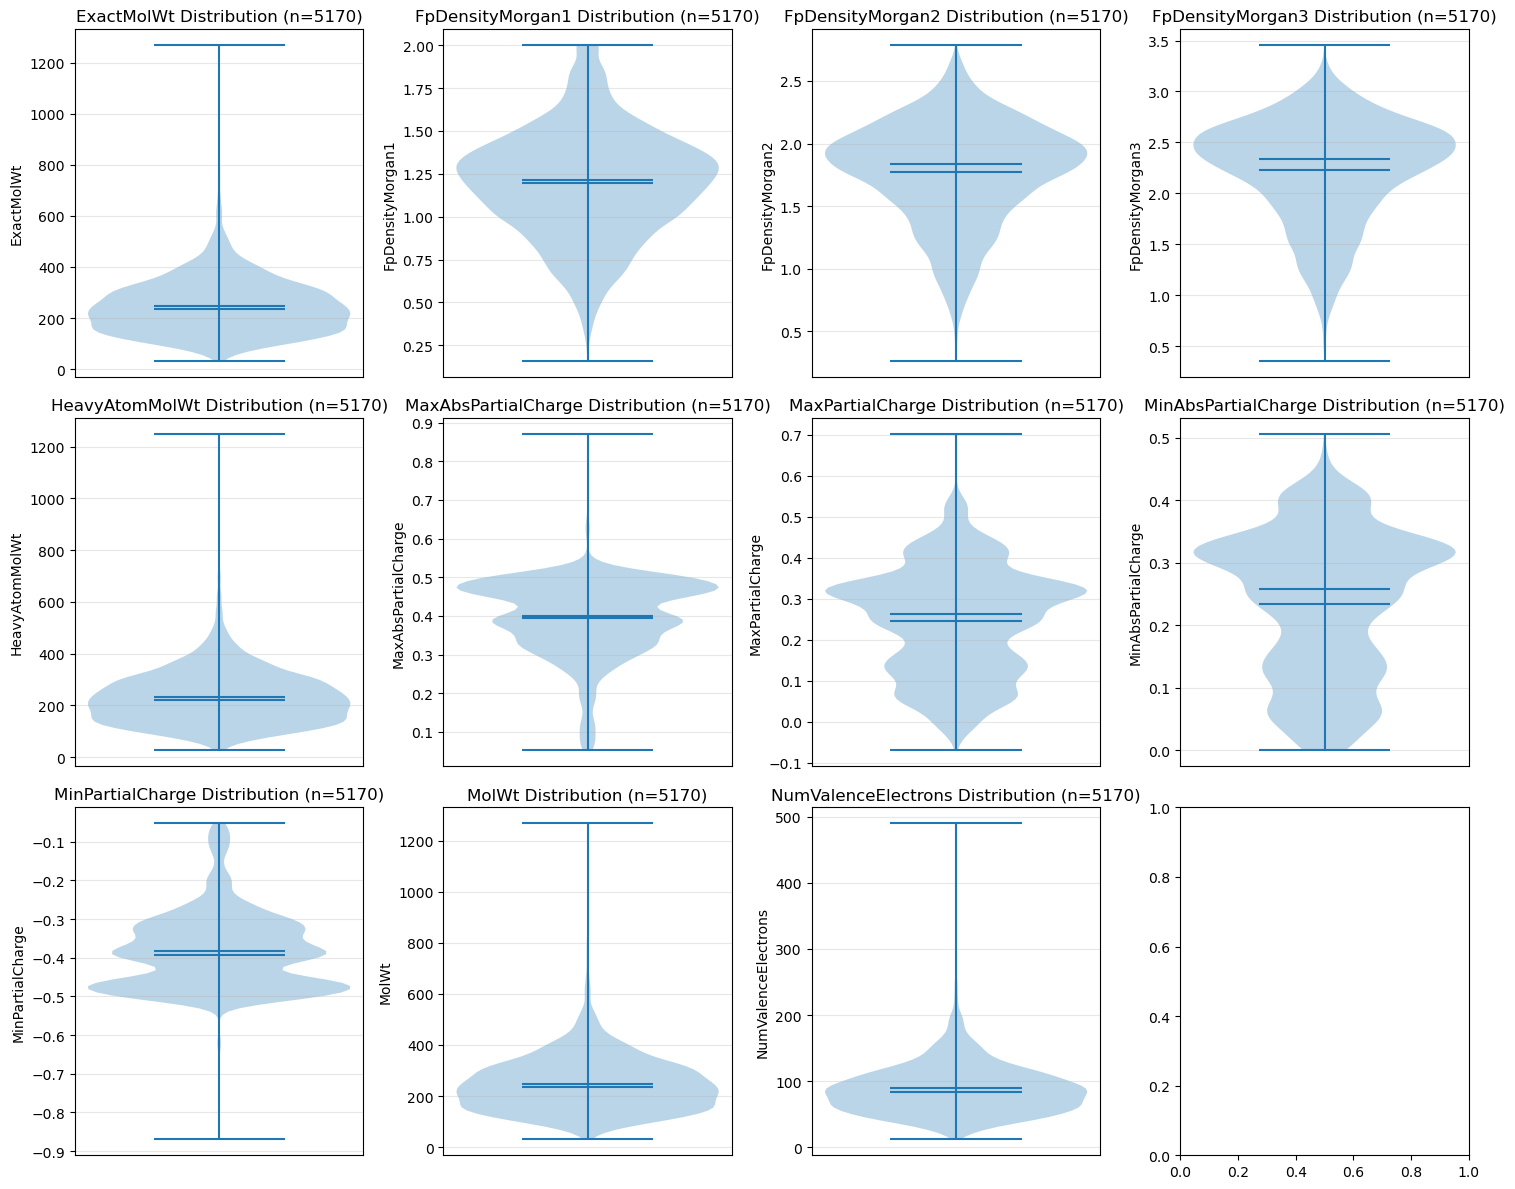


Descriptor Summary Statistics:
       ExactMolWt  FpDensityMorgan1  FpDensityMorgan2  FpDensityMorgan3  \
count    5170.000          5170.000          5170.000          5170.000   
mean      248.101             1.195             1.771             2.229   
std       114.973             0.318             0.406             0.504   
min        30.011             0.156             0.260             0.351   
25%       164.095             1.000             1.545             1.938   
50%       234.160             1.211             1.833             2.333   
75%       310.057             1.400             2.056             2.588   
max      1268.566             2.000             2.786             3.455   

       HeavyAtomMolWt  MaxAbsPartialCharge  MaxPartialCharge  \
count        5170.000             5170.000          5170.000   
mean          233.193                0.395             0.247   
std           109.648                0.098             0.131   
min            26.018               

In [28]:
# Feature distributions (Violin plots)
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(descriptor_cols):
    valid_data = df[col].dropna()
    axes[idx].violinplot(valid_data, positions=[0], widths=0.7, showmeans=True, showmedians=True)
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'{col} Distribution (n={len(valid_data)})')
    axes[idx].grid(alpha=0.3, axis='y')
    axes[idx].set_xticks([])

plt.tight_layout()
plt.show()

# Summary statistics per descriptor
print("\nDescriptor Summary Statistics:")
print(df[descriptor_cols].describe().round(3))

Feature Variability (Coefficient of Variation):
                        Mean      Std  CV (%)     Min       Max     Range
MaxPartialCharge       0.247    0.131  53.152  -0.070     0.701     0.771
MinAbsPartialCharge    0.235    0.116  49.441   0.000     0.506     0.506
HeavyAtomMolWt       233.193  109.648  47.020  26.018  1247.715  1221.697
NumValenceElectrons   89.157   41.487  46.532  12.000   490.000   478.000
MolWt                248.542  115.193  46.347  30.026  1268.883  1238.857
ExactMolWt           248.101  114.973  46.341  30.011  1268.566  1238.555
FpDensityMorgan1       1.195    0.318  26.580   0.156     2.000     1.844
MaxAbsPartialCharge    0.395    0.098  24.778   0.052     0.870     0.818
FpDensityMorgan2       1.771    0.406  22.941   0.260     2.786     2.526
FpDensityMorgan3       2.229    0.504  22.591   0.351     3.455     3.104
MinPartialCharge      -0.383    0.100 -25.994  -0.870    -0.052     0.818


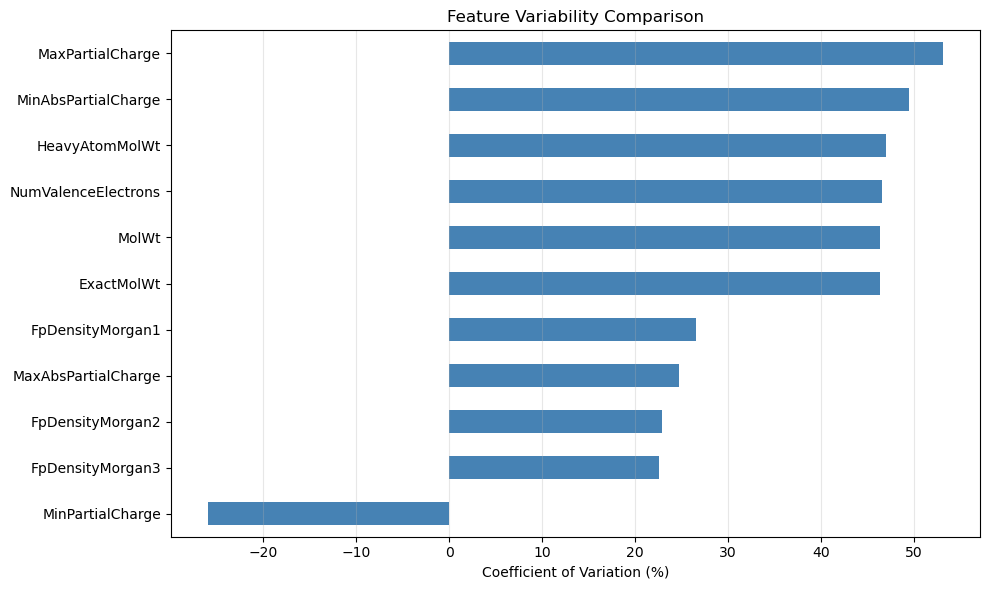

In [29]:
# Feature variability: Coefficient of Variation
cv_analysis = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()
    mean_val = valid_data.mean()
    std_val = valid_data.std()
    cv = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
    cv_analysis[col] = {
        'Mean': mean_val,
        'Std': std_val,
        'CV (%)': cv,
        'Min': valid_data.min(),
        'Max': valid_data.max(),
        'Range': valid_data.max() - valid_data.min()
    }

cv_df = pd.DataFrame(cv_analysis).T.sort_values('CV (%)', ascending=False)
print("Feature Variability (Coefficient of Variation):")
print(cv_df.round(3))

# Visualization: CV comparison
fig, ax = plt.subplots(figsize=(10, 6))
cv_df['CV (%)'].sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Feature Variability Comparison')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare data for PCA
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

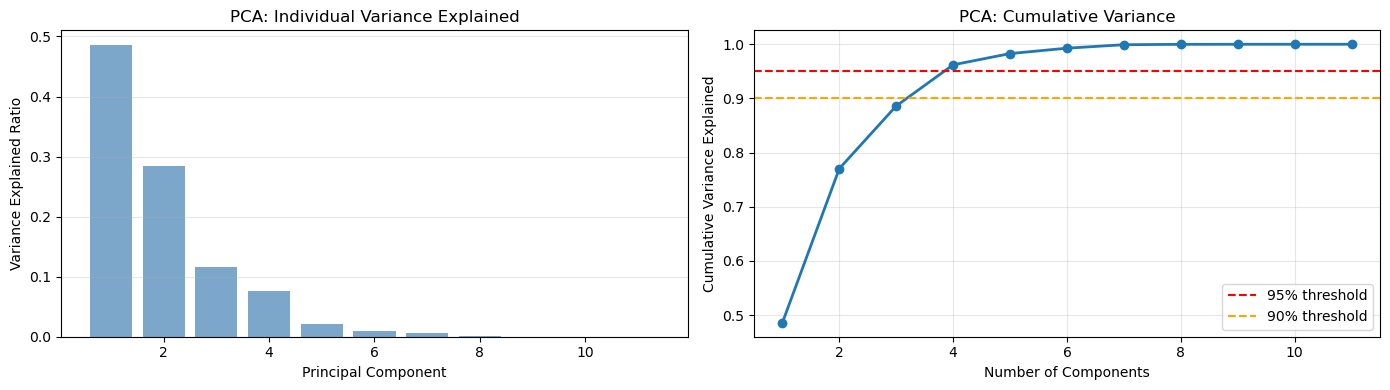

Components needed for 95% variance: 4/11
Variance explained by first 3 PCs: 0.886


In [31]:
# PCA: Dimensionality reduction & variance analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# Standardize data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Plot cumulative variance explained
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Individual variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('PCA: Individual Variance Explained')
axes[0].grid(alpha=0.3, axis='y')

# Cumulative variance
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'o-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('PCA: Cumulative Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find n_components for 95% variance
n_comps_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_comps_95}/{len(pca.explained_variance_ratio_)}")
print(f"Variance explained by first 3 PCs: {cumsum_var[2]:.3f}")

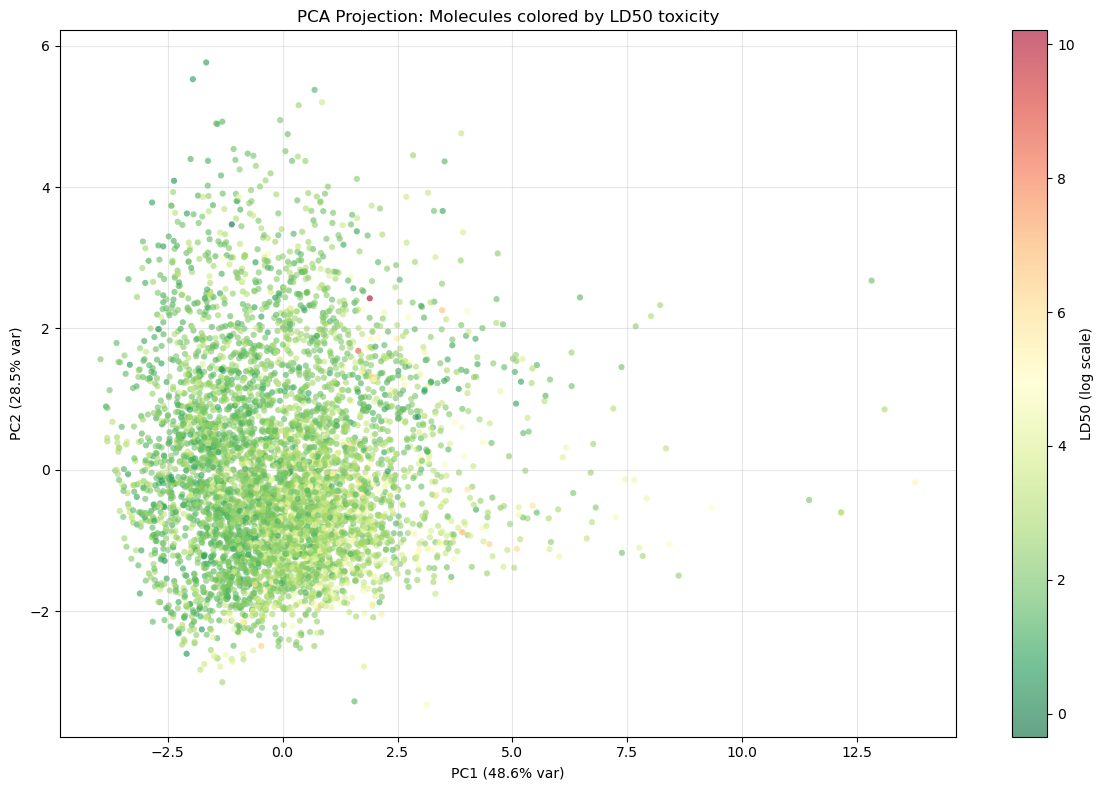


Feature Loadings (PC1 & PC2):
                       PC1    PC2
ExactMolWt           0.432 -0.045
FpDensityMorgan1    -0.277 -0.400
FpDensityMorgan2    -0.223 -0.476
FpDensityMorgan3    -0.117 -0.476
HeavyAtomMolWt       0.421 -0.047
MaxAbsPartialCharge  0.167 -0.356
MaxPartialCharge     0.161 -0.262
MinAbsPartialCharge  0.149 -0.267
MinPartialCharge    -0.133  0.332
MolWt                0.432 -0.045
NumValenceElectrons  0.464 -0.061


In [32]:
# 2D PCA projection: Molecules by toxicity
# Use first 2 PCs
X_pca_2d = pca.transform(X_scaled)[:, :2]

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn_r', s=20, alpha=0.6, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA Projection: Molecules colored by LD50 toxicity')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('LD50 (log scale)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature loading: which descriptors contribute most to PC1 & PC2
loadings = pca.components_[:2, :].T
loading_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=descriptor_cols)
print("\nFeature Loadings (PC1 & PC2):")
print(loading_df.round(3))

In [34]:
# ANOVA: Significance of features across toxicity groups
from scipy.stats import f_oneway, pearsonr

# Discretize target into 3 toxicity groups (low, medium, high)
y_groups = pd.qcut(df['Y'], q=3, labels=['Low', 'Medium', 'High'])

anova_results = {}
for col in descriptor_cols:
    valid_mask = df[col].notna()
    groups = [df[col][valid_mask & (y_groups == g)].values for g in ['Low', 'Medium', 'High']]
    
    # Remove empty groups
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('p-value', ascending=False)
print("ANOVA Results (Feature ~ Toxicity Groups):")
print(anova_df)
print("\nSignificant features (p < 0.05):", anova_df[anova_df['p-value'] < 0.05].shape[0])

ANOVA Results (Feature ~ Toxicity Groups):
                     F-statistic        p-value
MinPartialCharge        0.525925   5.910403e-01
FpDensityMorgan1        2.245257   1.060037e-01
FpDensityMorgan2        5.207527   5.503972e-03
MaxAbsPartialCharge     6.852923   1.065991e-03
FpDensityMorgan3       24.559212   2.423521e-11
MinAbsPartialCharge    95.169885   2.578285e-41
MaxPartialCharge      128.098895   5.042270e-55
NumValenceElectrons   153.257376   2.190775e-65
ExactMolWt            275.346702  2.352144e-114
MolWt                 276.275251  1.016481e-114
HeavyAtomMolWt        298.072615  3.073139e-123

Significant features (p < 0.05): 9


---
**Analisi esplorativa completata.** Dataset pronto per feature selection e modellazione.